### **Geometry & Material Setup**
To begin, we define the input variables -> the dimensions of the collimator and the material properties. Avogadro's number ($0.6022$) has been simplified for the conversion between atomic density and cross section in barns, so that the macroscopic cross section is calculated in $cm^{-1}$

In [12]:
# Just importing the necessary libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

xs = 2.0        # Source size (cm)
xcoll = 100.0   # Collimator length (cm)
xa = 10.0       # Surface a x-location (cm)
xb = 70.0       # Surface b x-location (cm)
wcoll = 50.0    # Collimator thickness (cm)

y_max = xs / 2.0 + wcoll
y_min = -xs / 2.0 - wcoll

N_A = 0.6022 # Avogadro's number * 10^-24 (shortcut for barns -> cm^-1 conversion)

# Polyethylene (C2H4)
rho_pe = 1.0 # g/cm^3
M_pe = 2*12.011 + 4*1.008 # g/mol
N_pe = (rho_pe * N_A) / M_pe 
N_C = 2 * N_pe 
N_H = 4 * N_pe 

# Lead-208
rho_pb = 11.35 # g/cm^3
M_pb = 208.0 # g/mol
N_Pb = (rho_pb * N_A) / M_pb 

masses = {'H': 1.0, 'C': 12.0, 'Pb': 208.0}

### **Data Loading & Interpolation**
This cell defines functions to load the CSV data and perform log-log interpolation. The interpolation also includes a zero check so that the cross section dropping to zero doesn't cause mathematical errors. 

The interpolation essentially finds a curve for the given data, and then uses it to find the microscopic cross section $\sigma$ at any energy, since the given CSV files don't have continuous data, just specific discreete points.

In [13]:
def load_xs_data(filename, delimiter=','):
    df = pd.read_csv(filename, delimiter=delimiter, header=None, comment='I') 
    df = df.apply(pd.to_numeric, errors='coerce').dropna()
    E = df.iloc[:, 0].values # eV
    xs = df.iloc[:, 1].values # barns
    return E, xs

def get_sigma(E, E_array, xs_array):
    """Log-log interpolation handling zero cross-sections safely.
    Inputs:
    - E: Energy to interpolate at (eV)
    - E_array: 1D array of energies (eV)
    - xs_array: 1D array of cross sections (barns)
    Output:
    - Interpolated cross section at energy E (barns)
    """
    if E <= E_array[0]: return xs_array[0]
    if E >= E_array[-1]: return xs_array[-1]
    
    # Safely handle exactly 0.0 cross sections to prevent log(0) warnings
    xs_safe = np.where(xs_array <= 0, 1e-30, xs_array)
    
    log_E = np.log(E)
    log_E_array = np.log(E_array)
    log_xs_array = np.log(xs_safe)
    
    # Uses the numpy interpolation function on the log-log data instead of manual interpolation
    log_sigma = np.interp(log_E, log_E_array, log_xs_array)
    sigma = np.exp(log_sigma)
    
    # Rounds very small cross sections to zero to avoid numerical issues
    return 0.0 if sigma < 1e-25 else sigma

# Load cross sections
E_H_scat, xs_H_scat = load_xs_data('H1_scat.csv')
E_H_abs, xs_H_abs = load_xs_data('H1_abs.csv')
E_C_scat, xs_C_scat = load_xs_data('c_scat.csv', delimiter=';') # Semicolon delimiter needed becase of formatting
E_C_abs, xs_C_abs = load_xs_data('c_abs.csv', delimiter=';')
E_Pb_scat, xs_Pb_scat = load_xs_data('pb_scat.csv')
E_Pb_abs, xs_Pb_abs = load_xs_data('pb_radcap.csv')

# Load Pu-Be Spectrum Data
spec_df = pd.read_csv('full_spectrum.csv')
spec_E = spec_df['Energy'].values * 1e6 # Convert MeV to eV because our cross sections are in eV
spec_Y = spec_df['Yield'].values # Load the yield data as is (no conversion needed)
max_yield = np.max(spec_Y)

### **Rejection Sampling**

The source spectrum is not known with a simple equation, so the code has to guess an energy and probability. If the guess falls under the experimental curve, it is accepted. It attempts to more accurately model a real world source.

In [14]:
def sample_source_energy():
    """Rejection sampling for Pu-Be source."""
    while True:
        E_guess = np.random.uniform(spec_E[0], spec_E[-1])
        Y_guess = np.random.uniform(0, max_yield)
        Y_actual = np.interp(E_guess, spec_E, spec_Y)
        if Y_guess < Y_actual:
            return E_guess

### **Geometry Functions**
in_collimator acts as a material map, checking the particles $(x, y)$ against the defined geometry. It basically just checks if the neutron is in the shielding or the void (or outside altogether)

get_distance_to_boundaries calculates the distance to all of six primary bounds (Surfaces D, E, F, a, b, and channel walls). It returns the smallest positive distance so that the simulation knows that surface the neutron will encounter first if it doesnt collide with anything.

In [15]:
def in_collimator(x, y, tol=1e-9):
    """Check if particle is in the solid material vs void channel.
    Inputs:
    - x, y: Particle coordinates (cm)
    - tol: Numerical tolerance for boundary checks (cm)
    Output:
    - True if in solid material, False if in void channel or outside geometry
    """
    if x <= 0 or x >= xcoll: return False
    if y >= (xs/2.0 - tol) and y <= y_max: return True
    if y <= (-xs/2.0 + tol) and y >= y_min: return True
    return False

def get_distance_to_boundaries(x, y, u, v):
    """Ray tracing math to calculate distance to all geometric surfaces.
    Inputs: 
    - x, y: Current particle coordinates (cm)
    - u, v: The direction cosines (unit vector components)
    Output:
    - distance to closest boundary (cm)
    - name of closest boundary
    """
    distances = {}
    
    # Vertical boundaries (x = constant)
    x_bounds = {'D': 0, 'a': xa, 'b': xb, 'F': xcoll}
    for name, xbnd in x_bounds.items():
        if u != 0:
            d = (xbnd - x) / u
            if d > 1e-10: distances[name] = d # 1e-10 avoids sticking to walls
            
    # Horizontal boundaries (y = constant)
    y_bounds = {'TopE': y_max, 'BotE': y_min, 'TopChannel': xs/2.0, 'BotChannel': -xs/2.0}
    for name, ybnd in y_bounds.items():
        if v != 0:
            d = (ybnd - y) / v
            if d > 1e-10: distances[name] = d
            
    if not distances:
        return np.inf, None
        
    closest_bound = min(distances, key=distances.get)
    return distances[closest_bound], closest_bound

### **Simulation Engine**

simulate_particle simulates a single neutron from the birth to absorption or escape. It samples the distance to collision ($d_{coll} = -\frac{\ln(1-\xi)}{\Sigma_t}$), handles elastic scattering to calculate energy loss, and tracks any boundary crossings for the overall data collection

In [16]:
def simulate_particle(material):
    """Runs a single particle history from birth to death/escape."""
    x = np.random.uniform(0, xs)
    y = np.random.uniform(-xs/2.0, xs/2.0)
    E = sample_source_energy()
    theta = np.random.uniform(0, 2*np.pi)
    u, v = np.cos(theta), np.sin(theta)
    
    status = 'alive'
    energy_dep = 0.0
    tallies = {'a_cross': [], 'b_cross': [], 'c_cross': [], 'esc_D': 0, 'esc_E': 0, 'esc_F': 0, 'absorbed': 0}
    
    while status == 'alive':
        # 1. Look up Macro Cross Sections
        if in_collimator(x, y):
            if material == 'PE':
                sig_H_s = get_sigma(E, E_H_scat, xs_H_scat)
                sig_H_a = get_sigma(E, E_H_abs, xs_H_abs)
                sig_C_s = get_sigma(E, E_C_scat, xs_C_scat)
                sig_C_a = get_sigma(E, E_C_abs, xs_C_abs)
                
                Sig_t = N_H * (sig_H_s + sig_H_a) + N_C * (sig_C_s + sig_C_a)
            else: # Pb
                sig_Pb_s = get_sigma(E, E_Pb_scat, xs_Pb_scat)
                sig_Pb_a = get_sigma(E, E_Pb_abs, xs_Pb_abs)
                Sig_t = N_Pb * (sig_Pb_s + sig_Pb_a)
                
            d_coll = -np.log(1.0 - np.random.uniform(0, 1)) / Sig_t
        else:
            Sig_t = 0.0
            d_coll = np.inf # Travels freely in void
            
        # 2. Ray tracing
        d_bound, bound_name = get_distance_to_boundaries(x, y, u, v)
        d_move = min(d_coll, d_bound)
        
        # 3. Move particle
        x += d_move * u
        y += d_move * v
        
        # 4. Handle Boundary Crossing
        if d_move == d_bound:
            if bound_name == 'D':
                tallies['esc_D'] = 1
                status = 'escaped'
            elif bound_name in ['TopE', 'BotE']:
                tallies['esc_E'] = 1
                status = 'escaped'
            elif bound_name == 'F':
                if abs(y) <= xs/2.0: # Exited the channel exactly (surface c)
                    tallies['c_cross'].append(E)
                tallies['esc_F'] = 1
                status = 'escaped'
            elif bound_name == 'a':
                tallies['a_cross'].append(E)
            elif bound_name == 'b':
                tallies['b_cross'].append(E)
            # If it hits TopChannel or BotChannel, the loop repeats and material updates seamlessly
                
        # 5. Handle Collision
        elif d_move == d_coll:
            # Determine Isotope for PE mixture
            if material == 'PE':
                Sig_C_t = N_C * (sig_C_s + sig_C_a)
                if np.random.uniform(0, 1) < (Sig_C_t / Sig_t):
                    iso, prob_scat = 'C', sig_C_s / (sig_C_s + sig_C_a)
                else:
                    iso, prob_scat = 'H', sig_H_s / (sig_H_s + sig_H_a)
            else:
                iso, prob_scat = 'Pb', sig_Pb_s / (sig_Pb_s + sig_Pb_a)
                
            # Scatter vs Capture
            if np.random.uniform(0, 1) < prob_scat: 
                # Elastic scatter kinematics
                A = masses[iso]
                mu_cm = np.random.uniform(-1, 1)
                E_new = E * ((A**2 + 2*A*mu_cm + 1) / ((A+1)**2))
                energy_dep += (E - E_new)
                E = E_new
                
                # Resample direction isotropically
                theta = np.random.uniform(0, 2*np.pi)
                u, v = np.cos(theta), np.sin(theta)
            else: 
                energy_dep += E
                tallies['absorbed'] = 1
                status = 'dead'
                
    return tallies, energy_dep

### **Simulation Executor**

This essentially runs the simulation for the number of histories we want, keeping track of all the data collected from each particle. It takes the most time, because it simulates every neutron through simulate_particle()

In [17]:
def run_simulation(material, n_histories):
    results = {
        'a_flux': [], 'b_flux': [], 'c_flux': [],
        'esc_D': 0, 'esc_E': 0, 'esc_F': 0, 'absorbed': 0,
        'tot_energy_dep': 0.0
    }
    for _ in range(n_histories):
        tallies, e_dep = simulate_particle(material)
        results['a_flux'].extend(tallies['a_cross'])
        results['b_flux'].extend(tallies['b_cross'])
        results['c_flux'].extend(tallies['c_cross'])
        results['esc_D'] += tallies['esc_D']
        results['esc_E'] += tallies['esc_E']
        results['esc_F'] += tallies['esc_F']
        results['absorbed'] += tallies['absorbed']
        results['tot_energy_dep'] += e_dep
        
    return results

### **Execution and Plotting**

Finally, we run two overall simulations (one for lead-208 and one for polyethylene (C2H4)). It then plots the results using the function built for that, which is designed to show the three graphs for each simulation next to each other, because I didn't like how it looked with each one printing out separately.

At the end, we print out the results for polyethylene and then for lead


RESULTS FOR POLYETHYLENE
Fraction exiting Surface 'c' (Channel Exit): 0.0045
Fraction absorbed in collimator:           0.3709
Fraction escaping Surface D (Back/Left):   0.6240
Fraction escaping Surface E (Top/Bottom):  0.0003
Fraction escaping Surface F (Front/Right): 0.0048
Total Fraction Escaping (D+E+F):           0.6291
Average total energy deposited per source particle: 2.56e+06 eV
Total number of neutrons absorbed: 18546


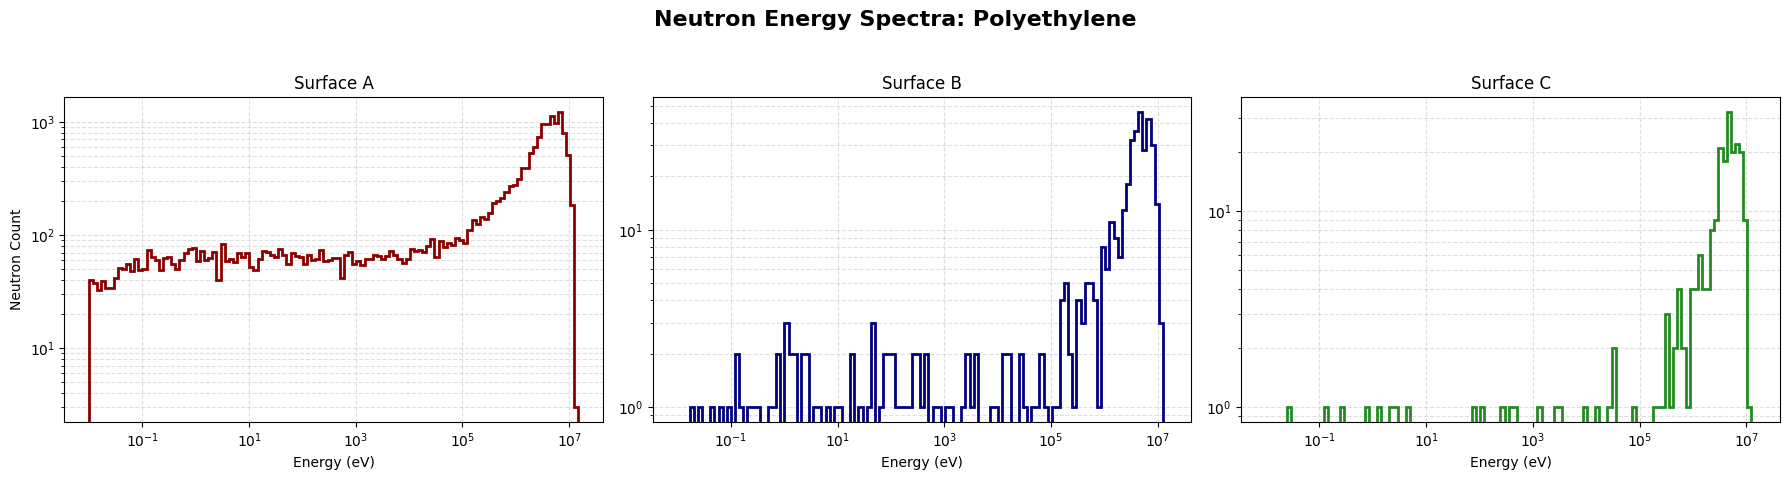


RESULTS FOR LEAD
Fraction exiting Surface 'c' (Channel Exit): 0.0058
Fraction absorbed in collimator:           0.0015
Fraction escaping Surface D (Back/Left):   0.8744
Fraction escaping Surface E (Top/Bottom):  0.0923
Fraction escaping Surface F (Front/Right): 0.0318
Total Fraction Escaping (D+E+F):           0.9985
Average total energy deposited per source particle: 4.20e+05 eV
Total number of neutrons absorbed: 77


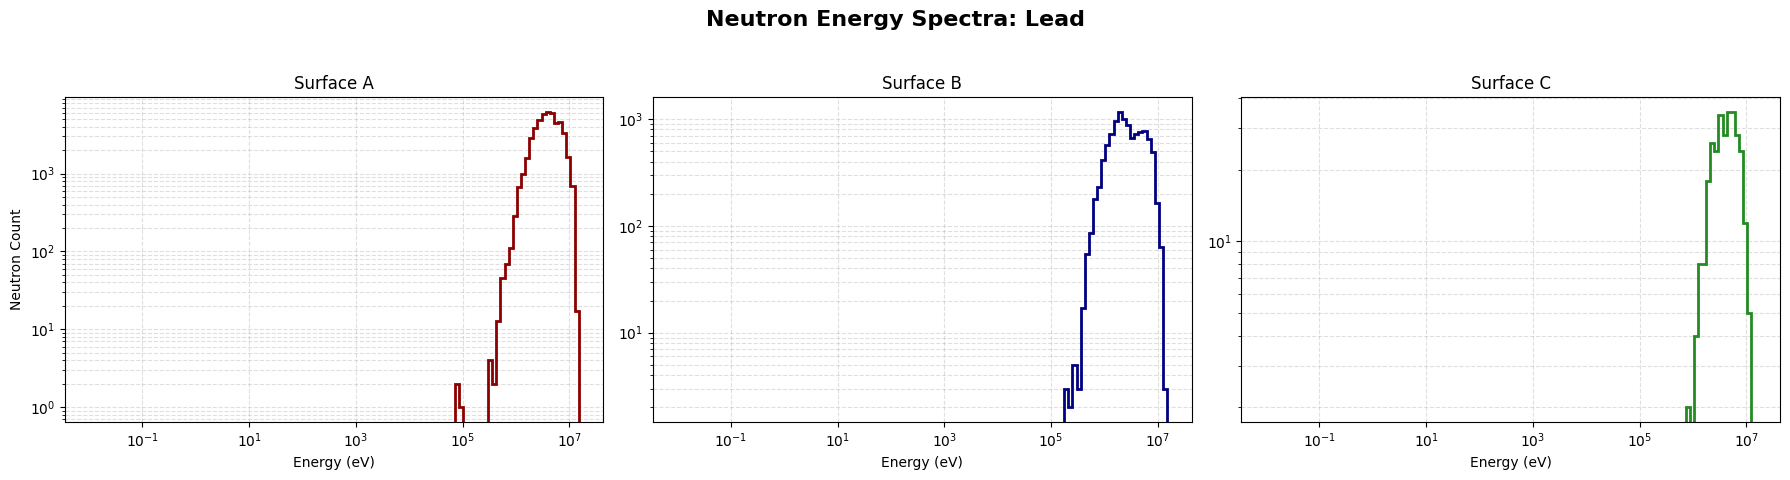

In [20]:
def plot_material_results(res, mat_name, max_E):
    """Creates a single row of 3 plots for a specific material."""
    # Create a figure with 1 row and 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Neutron Energy Spectra: {mat_name}', fontsize=16, fontweight='bold')

    # Define the surfaces we want to plot
    surfaces = [('a_flux', 'Surface A', 'darkred'), 
                ('b_flux', 'Surface B', 'navy'), 
                ('c_flux', 'Surface C', 'forestgreen')]

    bins = np.logspace(np.log10(0.01), np.log10(max_E), 120)

    for i, (key, title, color) in enumerate(surfaces):
        ax = axes[i]
        data = res[key]
        
        if data:
            ax.hist(data, bins=bins, histtype='step', linewidth=2, color=color)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_title(title)
            ax.set_xlabel('Energy (eV)')
            ax.set_ylabel('Neutron Count' if i == 0 else "") # Only label Y on the first plot, they are side by side
            ax.grid(True, which="both", ls="--", alpha=0.4)
        else:
            ax.text(0.5, 0.5, 'No Data Recorded', ha='center', va='center')
            ax.set_title(title)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust to make room for the title
    plt.show()

# Run the physics - 50,000 histories provides a solid dataset without taking forever, but still takes a long time
n_histories = 50000
results_pe = run_simulation('PE', n_histories)
results_pb = run_simulation('Pb', n_histories)

max_source_energy = spec_E[-1]


# Print the results in a clear format, a bit complicated to set up but it makes the output way easier to read and understand.
for mat_name, res in [('Polyethylene', results_pe), ('Lead', results_pb)]:
    print(f"\n{'='*40}\nRESULTS FOR {mat_name.upper()}\n{'='*40}")
    
    print(f"Fraction exiting Surface 'c' (Channel Exit): {len(res['c_flux']) / n_histories:.4f}")
    print(f"Fraction absorbed in collimator:           {res['absorbed'] / n_histories:.4f}")
    print(f"Fraction escaping Surface D (Back/Left):   {res['esc_D'] / n_histories:.4f}")
    print(f"Fraction escaping Surface E (Top/Bottom):  {res['esc_E'] / n_histories:.4f}")
    print(f"Fraction escaping Surface F (Front/Right): {res['esc_F'] / n_histories:.4f}")
    print(f"Total Fraction Escaping (D+E+F):           {(res['esc_D'] + res['esc_E'] + res['esc_F']) / n_histories:.4f}")
    
    print(f"Average total energy deposited per source particle: {res['tot_energy_dep'] / n_histories:.2e} eV")
    print(f"Total number of neutrons absorbed: {res['absorbed']}")
    
    # Generate the 3 plots per material
    plot_material_results(res, mat_name, max_source_energy)


### **Conclusion**

**Polyethelyne** is the material I would choose to construct a collimator with. The purpose of a collimator is to shape and slow down the beam of neutrons so that they are easier to control and use. The lead graphs show that the neutrons never really slow down lead is heavy so they mostly just reflect, while the PE graphs show how neutrons that dont collide flow to the exit like we want, while the neutrons that collide lose most of their energy between surface A and C.

The main difference is also the difference in their strenghts. Polyethelyne controls neutrons a lot, absorbing most of the energy from collisions to keep the beam stable and slower. Lead reflects a lot of neutrons, making it effective for shielding meant to stop passage of neutrons but less effective at slowing down and controlling a beam of neutrons through a channel.

The polyethelyne moderates the neutrons more, and that is the purpose of a collimator.